## TLS analysis
### Selected regions with TLS across samples were first analysed seperately 

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import os

In [5]:
# Load data
TLS_107_314 = sc.read_h5ad("MH107_TLS_314_ss_cropped_#1.h5ad")
TLS_104_314 = sc.read_h5ad("MH104_TLS_314_ss_cropped_#1.h5ad")
TLS_065_314 = sc.read_h5ad("MH065_TLS_314_ss_cropped_#1.h5ad")
TLS_096_480_n2 = sc.read_h5ad("MH096_TLS_480_ss_cropped_#2.h5ad")
TLS_096_480_n1 = sc.read_h5ad("MH096_TLS_480_ss_cropped_#1.h5ad")
TLS_097_480_n3 = sc.read_h5ad("MH097_TLS_480_ss_cropped_#3.h5ad")
TLS_097_480_n2 = sc.read_h5ad("MH097_TLS_480_ss_cropped_#2.h5ad")
TLS_097_480_n1 = sc.read_h5ad("MH097_TLS_480_ss_cropped_#1.h5ad")

In [6]:
SLS_ref = sc.read_h5ad("MH104_SLS_480plex_setseed.h5ad")

In [19]:
TLS_TNBC_1 = sc.read_h5ad("Xenium_BreastTLS_0010466top_cropped.h5ad")
TLS_TNBC_2 = sc.read_h5ad("BreastTLS_0010466b_cropped.h5ad")
TLS_TNBC_3 = sc.read_h5ad("BreastTLS_0010544top_cropped.h5ad")
TLS_TNBC_4 = sc.read_h5ad("BreastTLS_0010544b_cropped.h5ad")

##### PDAC TLS list

In [10]:
tls_list = [
    TLS_107_314, TLS_104_314, TLS_065_314, TLS_096_480_n2,
    TLS_096_480_n1,TLS_097_480_n3,TLS_097_480_n2,TLS_097_480_n1,SLS_ref
]
# Initialize lists to hold counts
tls_names = [
    "TLS_107_314", "TLS_104_314","TLS_065_314","TLS_096_480_n2",
    "TLS_096_480_n1","TLS_097_480_n3","TLS_097_480_n2","TLS_097_480_n1","SLS_ref"
]

In [25]:
tls_data = {
    "TLS_107_314": TLS_107_314.obs["TLS_cell_class_threshold"],
    "TLS_104_314": TLS_104_314.obs["TLS_cell_class_threshold"],
    "TLS_065_314": TLS_065_314.obs["TLS_cell_class_threshold"],
    "TLS_096_480_n2": TLS_096_480_n2.obs["TLS_cell_class_threshold"],
    "TLS_096_480_n1": TLS_096_480_n1.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n3": TLS_097_480_n3.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n2": TLS_097_480_n2.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n1": TLS_097_480_n1.obs["TLS_cell_class_threshold"],
}

# Build long-form DataFrame
df_all = pd.concat(
    [pd.DataFrame({"TLS_ID": tls_id, "cell_type": values}) for tls_id, values in tls_data.items()],
    ignore_index=True
)

##### TNBC TLS list

In [20]:
tnbc_list = [TLS_TNBC_1, TLS_TNBC_2, TLS_TNBC_3, TLS_TNBC_4]
tnbc_names = ["TNBC_1","TNBC_2","TNBC_3", "TNBC_4"]

In [21]:
tnbc_data = {
    "TNBC_1": TLS_TNBC_1.obs["TLS_cell_class_threshold"],
    "TNBC_2": TLS_TNBC_2.obs["TLS_cell_class_threshold"],
    "TNBC_3": TLS_TNBC_3.obs["TLS_cell_class_threshold"],
    "TNBC_4": TLS_TNBC_4.obs["TLS_cell_class_threshold"],
   
}

# Build long-form DataFrame
df_tnbc = pd.concat(
    [pd.DataFrame({"TLS_ID": tls_id, "cell_type": values}) for tls_id, values in tnbc_data.items()],
    ignore_index=True
)

##### Combined all TLSs

In [19]:
merged_data = {
    "TLS_107_314": TLS_107_314.obs["TLS_cell_class_threshold"],
    "TLS_104_314": TLS_104_314.obs["TLS_cell_class_threshold"],
    "TLS_065_314": TLS_065_314.obs["TLS_cell_class_threshold"],
    "TLS_096_480_n2": TLS_096_480_n2.obs["TLS_cell_class_threshold"],
    "TLS_096_480_n1": TLS_096_480_n1.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n3": TLS_097_480_n3.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n2": TLS_097_480_n2.obs["TLS_cell_class_threshold"],
    "TLS_097_480_n1": TLS_097_480_n1.obs["TLS_cell_class_threshold"],
    "SLS_ref": SLS_ref.obs["TLS_cell_class_threshold"],
    "TNBC_1": TLS_TNBC_1.obs["TLS_cell_class_threshold"],
    "TNBC_2": TLS_TNBC_2.obs["TLS_cell_class_threshold"],
    "TNBC_3": TLS_TNBC_3.obs["TLS_cell_class_threshold"],
    "TNBC_4": TLS_TNBC_4.obs["TLS_cell_class_threshold"],
}

# Build long-form DataFrame
df_merged = pd.concat(
    [pd.DataFrame({"TLS_ID": tls_id, "cell_type": values}) for tls_id, values in merged_data.items()],
    ignore_index=True)

### Cellular composition across TLSs in PDAC

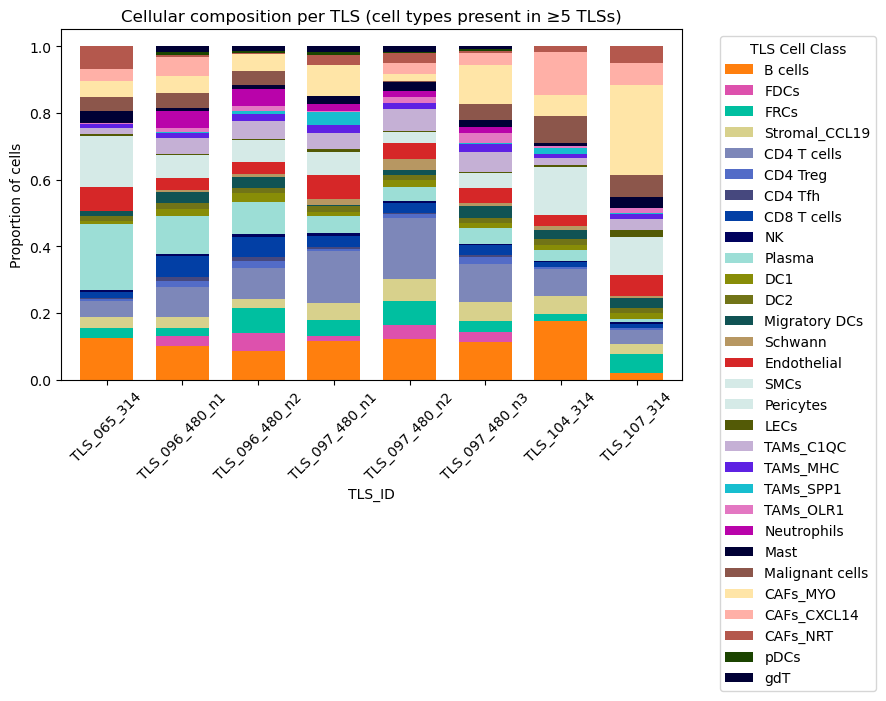

In [26]:
# Count presence of each cell type across TLSs
tls_presence = df_all.drop_duplicates().groupby("cell_type")["TLS_ID"].nunique()

# Keep only those present in ≥5 TLSs
# Remove 'Unclassified' or 'Unassigned'
consistent_cell_types = [
    c for c in tls_presence[tls_presence >= 5].index
    if c not in ['Unclassified', 'Unassigned']
]

# Filter original DataFrame
df_filtered = df_all[df_all["cell_type"].isin(consistent_cell_types)]

comp = (
    df_filtered.groupby(["TLS_ID", "cell_type"])
    .size()
    .reset_index(name="count")
)

comp["proportion"] = comp.groupby("TLS_ID")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = comp.pivot(index="TLS_ID", columns="cell_type", values="proportion").fillna(0)

# order classes
ordered_classes = consistent_cell_types
pivot = pivot[ordered_classes[::-1]]  # reverse for stacking order

custom_order = [ 'B cells', 'FDCs', 'FRCs', 'Stromal_CCL19',  'CD4 T cells','CD4 Treg', 'CD4 Tfh',
                'CD8 T cells','NK', 'Plasma', 'DC1', 'DC2', 'Migratory DCs', 
                'Schwann', 'Endothelial','SMCs',  'Pericytes','LECs',
                'TAMs_C1QC', 'TAMs_MHC', 'TAMs_SPP1', 'TAMs_OLR1','Neutrophils','Mast', 'Malignant cells', 
                 'CAFs_MYO', 'CAFs_CXCL14','CAFs_NRT','pDCs', 'gdT'
]

# Keep only those that are present in pivot
custom_order = [c for c in custom_order if c in pivot.columns]

# Reorder pivot
pivot = pivot[custom_order]

# Plot
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    width=0.7,
    color=[color_map[c] for c in pivot.columns]
)

plt.ylabel("Proportion of cells")
plt.title("Cellular composition per TLS (cell types present in ≥5 TLSs)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='TLS Cell Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Schwann cells in PDAC TLS

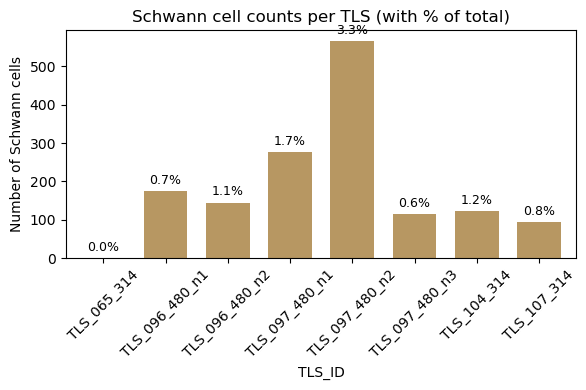

In [ ]:
# Counts
schwann_counts = (
    comp[comp["cell_type"] == "Schwann"]
    .set_index("TLS_ID")["count"]
    .reindex(pivot.index, fill_value=0)   # include all TLSs
)

# Percentages (×100 for %)
schwann_perc = pivot["Schwann"] * 100

# Plot counts
ax = schwann_counts.plot(
    kind="bar",
    figsize=(6,4),
    color="#b79762",   # Schwann colour
    width=0.7
)

# Add percentage labels above bars
for i, (count, perc) in enumerate(zip(schwann_counts, schwann_perc)):
    ax.text(i, count + max(schwann_counts)*0.02,   # just above bar
            f"{perc:.1f}%", 
            ha="center", va="bottom", fontsize=9)

plt.ylabel("Number of Schwann cells")
plt.xlabel("TLS_ID")
plt.title("Schwann cell counts per TLS (with % of total)")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig(f"Schwann_counts.pdf")
plt.show()

### Comparing cellular composition across lymph node, TLS in PDAC and TLS in TNBC

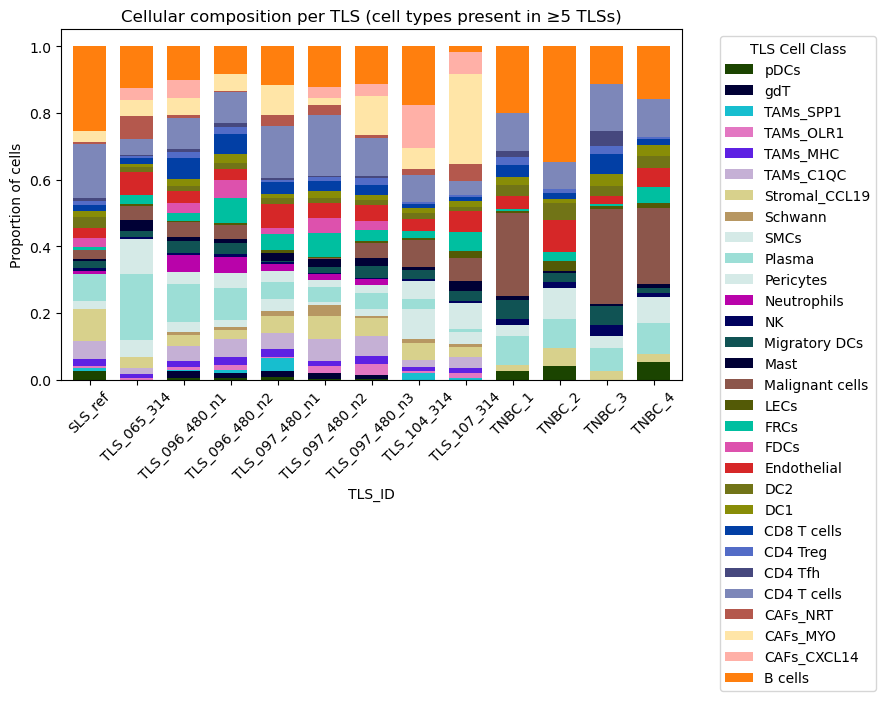

In [21]:
# Filter original DataFrame
df_filtered = df_merged[df_merged["cell_type"].isin(consistent_cell_types)]

# Count & normalize per TLS
comp = (
    df_filtered.groupby(["TLS_ID", "cell_type"])
    .size()
    .reset_index(name="count")
)

comp["proportion"] = comp.groupby("TLS_ID")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = comp.pivot(index="TLS_ID", columns="cell_type", values="proportion").fillna(0)

ordered_classes = consistent_cell_types
pivot = pivot[ordered_classes[::-1]]  # reverse for stacking order

# Plot
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    width=0.7,
    color=[color_map[c] for c in pivot.columns]
)

plt.ylabel("Proportion of cells")
plt.title("Cellular composition per TLS (cell types present in ≥5 TLSs)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='TLS Cell Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Broad cell class composition

In [24]:
# Set up
adata_list = [
    TLS_107_314, TLS_104_314, TLS_065_314, TLS_096_480_n2,
    TLS_096_480_n1,TLS_097_480_n3,TLS_097_480_n2,TLS_097_480_n1,
    SLS_ref, 
    TLS_TNBC_1, TLS_TNBC_2, TLS_TNBC_3, TLS_TNBC_4
]

# Corresponding sample names
sample_names = [
    "TLS_107_314", "TLS_104_314","TLS_065_314","TLS_096_480_n2",
    "TLS_096_480_n1","TLS_097_480_n3","TLS_097_480_n2","TLS_097_480_n1",
    "SLS_ref",
    "TNBC_1","TNBC_2","TNBC_3", "TNBC_4"
]

for adata, name in zip(adata_list, sample_names):
    adata.obs['sample'] = name

# Concatenate adata 
import anndata as ad
adata_all = ad.concat(adata_list, label="batch", keys=sample_names)

import pandas as pd

# Count cells per (sample, broad_cell_class)
composition = (
    adata_all.obs.groupby(['sample', 'broad_cell_class'])
    .size()
    .reset_index(name='count')
)

# Normalize to get proportions (optional)
composition['proportion'] = (
    composition.groupby('sample')['count']
    .transform(lambda x: x / x.sum())
)

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for plotting
composition_pivot = composition.pivot(index='sample', columns='broad_cell_class', values='proportion').fillna(0)

/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1898: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
column_list = composition_pivot.columns.tolist()

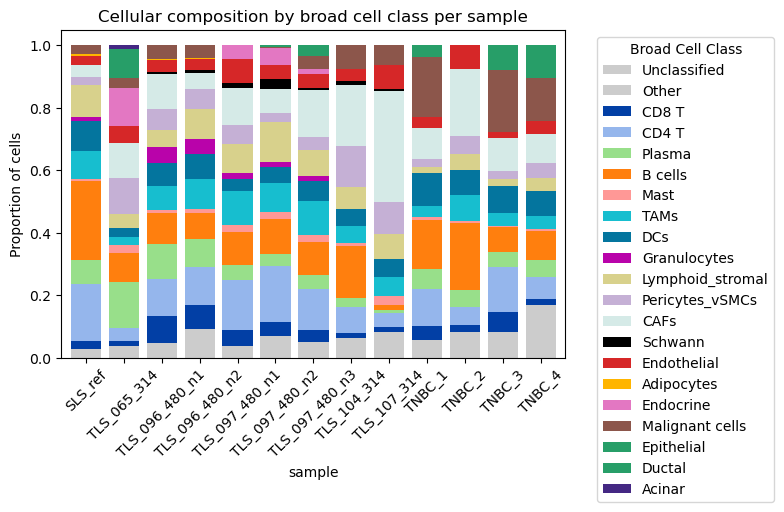

In [27]:
cell_class_order = ['Acinar','Ductal','Epithelial','Malignant cells','Endocrine',
                    'Adipocytes','Endothelial','Schwann','CAFs','Pericytes_vSMCs', 'Lymphoid_stromal',
                     'Granulocytes','DCs','TAMs',
                    'Mast','B cells','Plasma', 'CD4 T','CD8 T', 'Other','Unclassified']

# Reorder columns and reverse for correct stacking order (top to bottom)
ordered_columns = [c for c in cell_class_order if c in composition_pivot.columns]
composition_pivot = composition_pivot[ordered_columns[::-1]]  # reverse for stack order

class_colors = {'Acinar': "#442883", #'#ff7f0e',#'#e377c2', #checked pink
                'Ductal':'#279e68',# dark green
                'Epithelial': "#279e68", # deep purple
                'Malignant cells': '#8c564b', #checked
                'Endocrine':'#e377c2', #'#809693', #'#637845' #new col - deep green
                'Adipocytes': '#ffb500', #bright orange
                'Endothelial':'#d62728',# pink
                'Schwann': 'black',#'#b79762', #checked
                'CAFs': '#d5eae7', #checked
                'Pericytes_vSMCs':'#c5b0d5', #checked
                'Lymphoid_stromal':'#D8D18C', #'#ff9896', #'#8e063b', #deep red
                'Granulocytes': '#b903aa', #new col
                'DCs': '#04759E', #"#5E21E3",
                'TAMs':'#17becf', #checked
                'Mast':'#ff9896', # 'black',
                'B cells':'#ff7f0e',#'#aa40fc', #'#ff7f0e', # orange
                'Plasma':'#98df8a', #light green 
                'CD4 T':'#95B6EC', #'#7d87b9', #light blue
                'CD8 T':'#023fa5', #deep blue 
                'Unclassified':"#cccccc",
                'Other': "#cccccc",
}

# Plot with custom colors
composition_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    width=0.8,
    color=[class_colors[c] for c in composition_pivot.columns]
)

plt.ylabel("Proportion of cells")
plt.title("Cellular composition by broad cell class per sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Broad Cell Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Neighbourhood analysis using B-cell as centre cell in PDAC lymph node and TLS

In [11]:
results_by_sample = {}

# Loop over all samples
for adata, sample_name in zip(tls_list, tls_names):
    print(f"Processing {sample_name}...")

    df = analyze_neighbors_avg_per_cell_type(
        adata=adata,
        center_label="B cells",
        radius=50,
        label_key="TLS_cell_class_threshold",
        spatial_key="spatial"
    )

    results_by_sample[sample_name] = df

Processing TLS_107_314...
Processing TLS_104_314...
Processing TLS_065_314...
Processing TLS_096_480_n2...
Processing TLS_096_480_n1...
Processing TLS_097_480_n3...
Processing TLS_097_480_n2...
Processing TLS_097_480_n1...
Processing SLS_ref...


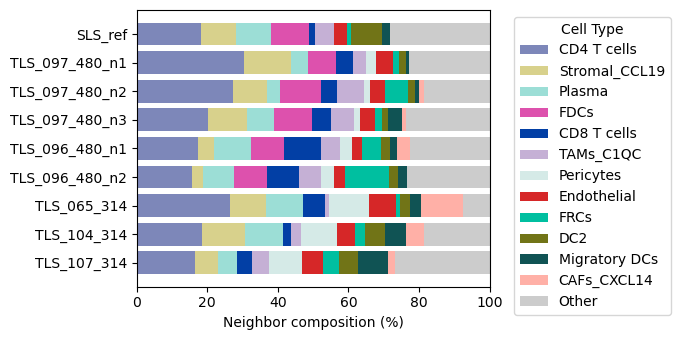

In [14]:
# Extract rows for malignant neighborhood composition
combined = []
for sample_name, series in results_by_sample.items():
    if isinstance(series, pd.Series):
        series.name = sample_name
        combined.append(series)

summary_df = pd.DataFrame(combined).fillna(0)

# Remove 'Unclassified'
if "Unclassified" in summary_df.columns:
    summary_df = summary_df.drop(columns=["Unclassified"])

# Find top cell types across all samples
top_cell_types = summary_df.sum().sort_values(ascending=False).head(12).index

# Collapse others into 'Other'
collapsed = summary_df[top_cell_types].copy()
collapsed["Other"] = summary_df.drop(columns=top_cell_types).sum(axis=1)

# Estimate total malignant cells from relative fraction sum
total_cells = {sample: int(row.sum() * 100) for sample, row in summary_df.iterrows()}

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))
bottom = np.zeros(len(collapsed))
y_pos = np.arange(len(collapsed))

for ct in collapsed.columns:
    values = collapsed[ct].values * 100
    ax.barh(y_pos, values, left=bottom, label=ct, color=manual_colors.get(ct, "#cccccc"))
    bottom += values

# Final plot formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(collapsed.index)
ax.set_xlim(0, 100)
ax.set_xlabel("Neighbor composition (%)")
ax.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

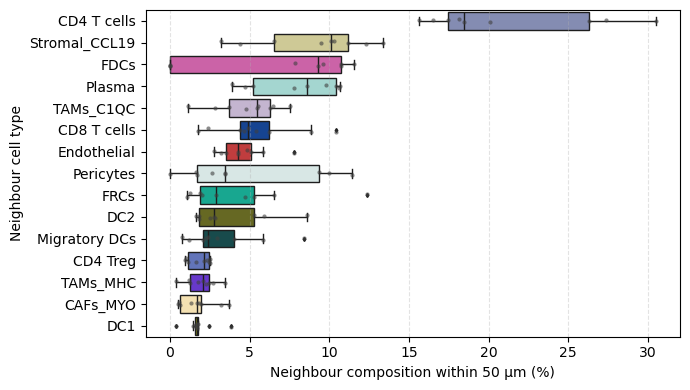

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

wide = pd.DataFrame(results_by_sample).T  # rows = samples, cols = neighbors (fractions)
wide = wide.fillna(0)

if any(col.endswith("_mean") for col in wide.columns):
    wide = wide[[c for c in wide.columns if c.endswith("_mean")]].copy()
    wide.columns = [c[:-5] for c in wide.columns]  # remove "_mean"

# Drop unwanted labels 
wide = wide.drop(columns=[c for c in ["Unclassified", "Unassigned"] if c in wide.columns], errors="ignore")
wide_pct = wide * 100

# Rank neighbors by median across samples
med_across_samples = wide_pct.median(axis=0).sort_values(ascending=False)

# Keep top cell types to show
topk = med_across_samples.head(min(15, len(med_across_samples))).index.tolist()

# Long format for plotting (only top k neighbors)
long = (
    wide_pct[topk]
    .reset_index()
    .rename(columns={"index": "sample"})
    .melt(id_vars="sample", var_name="neighbor", value_name="percent")
)

# Order neighbors by their cross-sample median
order = med_across_samples.loc[topk].index.tolist()

# Plotting
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=long, x="percent", y="neighbor",
    palette=manual_colors,
    order=order, fliersize=2, linewidth=1
)
sns.stripplot(
    data=long, x="percent", y="neighbor",
    order=order, color=".25", size=3, jitter=True, alpha=0.6
)
plt.xlabel("Neighbour composition within 50 µm (%)")
plt.ylabel("Neighbour cell type")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

### Neighbourhood enrichment analysis using Squidpy's squidpy.gr.nhood_enrichment() 

In [32]:
# Assume: a dictionary of samples
tls_dict = {
    "TLS_107_314": TLS_107_314,
    "TLS_104_314": TLS_104_314,
    "TLS_065_314": TLS_065_314,
    "TLS_096_480_n2": TLS_096_480_n2,
    "TLS_096_480_n1": TLS_096_480_n1,
    "TLS_097_480_n3": TLS_097_480_n3,
    "TLS_097_480_n2": TLS_097_480_n2,
    "TLS_097_480_n1": TLS_097_480_n1,
    #"SLS_ref": SLS_ref,
}
z_matrices = {}
for name, ad in tls_dict.items():
    z = ad.uns["TLS_cell_class_threshold_nhood_enrichment"]["zscore"]
    labels = ad.obs["TLS_cell_class_threshold"].cat.categories
    z_df = pd.DataFrame(z, index=labels, columns=labels)
    z_matrices[name] = z_df
    
# Stack each matrix, add sample name, and combine
z_long_list = []
for sample_name, z_df in z_matrices.items():
    z_long = z_df.stack().reset_index()
    z_long.columns = ["cluster_1", "cluster_2", "zscore"]
    z_long["sample"] = sample_name
    z_long_list.append(z_long)

z_combined = pd.concat(z_long_list, ignore_index=True)

In [33]:
# Define target cell types and thresholds
#target_types = ["FDCs", "FRCs", "Stromal_CCL19"]
target_types = ["FDCs", "FRCs", "Stromal_CCL19","Migratory DCs", "TAMs_C1QC","CAFs_NRT"]

min_samples = 3
score_threshold = 0.5

top_neighbors_by_type = {}

for cell_type in z_combined["cluster_1"].unique():
    if cell_type not in target_types:
        continue

    df = z_combined[z_combined["cluster_1"] == cell_type].copy()
    df = df[~df["cluster_2"].isin(["Unassigned", "Unclassified"])]
    df = df[df["cluster_1"] != df["cluster_2"]]

    # Normalize per sample
    df["zscore_minmax"] = df.groupby("sample")["zscore"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min())
    )

    # Aggregate
    agg = (
        df.groupby("cluster_2")
        .agg(
            mean_score=("zscore_minmax", "mean"),
            n_samples=("sample", "nunique")
        )
        .reset_index()
    )

    # Apply both filters
    agg = agg[(agg["n_samples"] >= min_samples) & (agg["mean_score"] >= score_threshold)]

    # Pick top neighbors by score
    top_n =4
    top_neighbors_by_type[cell_type] = agg.sort_values("mean_score", ascending=False).head(top_n)

In [34]:
# Combine results into a single DataFrame
top_neighbors_df = (
    pd.concat(top_neighbors_by_type, names=["Cell_Type"])
    .reset_index()
    .rename(columns={"cluster_2": "Neighbor", "n_samples": "Samples_enriched_in"})
)

top_neighbors_df = top_neighbors_df.sort_values(
    ["Cell_Type", "Samples_enriched_in"],
    ascending=[True, False]
)

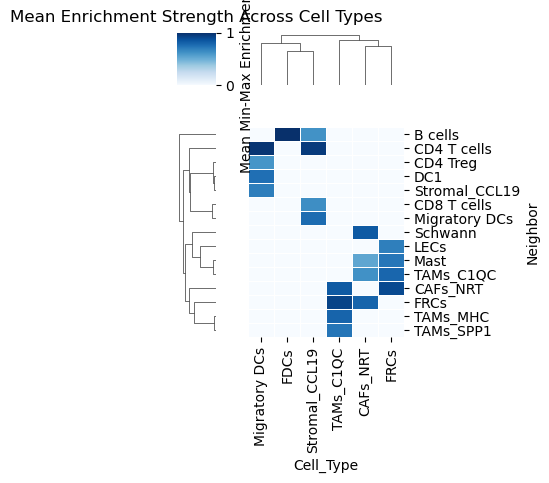

In [35]:
heatmap_scores = top_neighbors_df.pivot(
    index="Neighbor", columns="Cell_Type", values="mean_score"
).fillna(0)

sns.clustermap(
    heatmap_scores,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    row_cluster=True,
    col_cluster=True,
    figsize=(4, 5),
    cbar_kws={"label": "Mean Min-Max Enrichment Score"}
)
plt.title("Mean Enrichment Strength Across Cell Types", y=1.05)
plt.tight_layout()
plt.show()

### TLS analysis in TNBC

In [22]:
results_by_sample = {}

# Loop over all samples
for adata, sample_name in zip(tnbc_list, tnbc_names):
    print(f"Processing {sample_name}...")

    df = analyze_neighbors_avg_per_cell_type(
        adata=adata,
        center_label="B cells",
        radius=50,
        label_key="TLS_cell_class_threshold",
        spatial_key="spatial"
    )

    results_by_sample[sample_name] = df

Processing TNBC_1...
Processing TNBC_2...
Processing TNBC_3...
Processing TNBC_4...


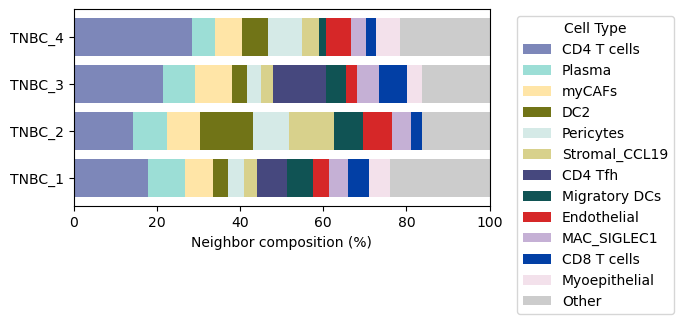

In [23]:
# Extract rows for malignant neighborhood composition
combined = []
for sample_name, series in results_by_sample.items():
    if isinstance(series, pd.Series):
        series.name = sample_name
        combined.append(series)

summary_df = pd.DataFrame(combined).fillna(0)

# Remove 'Unclassified' 
if "Unclassified" in summary_df.columns:
    summary_df = summary_df.drop(columns=["Unclassified"])

# Find top 6 cell classes
top_cell_types = summary_df.sum().sort_values(ascending=False).head(12).index

# Collapse others into 'Other'
collapsed = summary_df[top_cell_types].copy()
collapsed["Other"] = summary_df.drop(columns=top_cell_types).sum(axis=1)

# Estimate total malignant cells from relative fraction sum
total_cells = {sample: int(row.sum() * 100) for sample, row in summary_df.iterrows()}

manual_colors = {
   'B cells':  '#ff7f0e',
    'myCAFs': '#FFE5A7', #'#c7c7c7',
    'iCAFs': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD8 T cells":'#023fa5',
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Myoepithelial": '#f3e1eb',#'#00846f',
    "Endothelial":'#d62728',
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "MAC_SIGLEC1":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "pDCs":'#1b4400',
    'Stromal_CCL19': '#D8D18C', 
    "Other": "#cccccc"
}
# Plot
fig, ax = plt.subplots(figsize=(7, 3))
bottom = np.zeros(len(collapsed))
y_pos = np.arange(len(collapsed))

for ct in collapsed.columns:
    values = collapsed[ct].values * 100
    ax.barh(y_pos, values, left=bottom, label=ct, color=manual_colors.get(ct, "#cccccc"))
    bottom += values

# Final plot formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(collapsed.index)
ax.set_xlim(0, 100)
ax.set_xlabel("Neighbor composition (%)")
ax.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
import scanpy as sc

# Your AnnData objects
adatas = [TLS_TNBC_1, TLS_TNBC_2, TLS_TNBC_3, TLS_TNBC_4]

# 1) Get total cells in each object
for i, ad in enumerate(adatas, start=1):
    print(f"TLS_TNBC_{i}: {ad.n_obs} cells")

# 2) Combine all cells into one AnnData object
combined = adatas[0].concatenate(adatas[1:], batch_key="sample", batch_categories=["TLS_TNBC_1","TLS_TNBC_2","TLS_TNBC_3","TLS_TNBC_4"])

print(f"Combined: {combined.n_obs} cells")

TLS_TNBC_1: 54017 cells
TLS_TNBC_2: 33210 cells
TLS_TNBC_3: 46852 cells
TLS_TNBC_4: 38315 cells


/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1823: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


Combined: 172394 cells


### Neighbourhood enrichment analysis of TLS in TNBC (n=4)

In [40]:
# Assume: a dictionary of samples
tnbc_dict = {
    "TNBC_1": TLS_TNBC_1,
    "TNBC_2": TLS_TNBC_2,
    "TNBC_3": TLS_TNBC_3,
    "TNBC_4": TLS_TNBC_4,
   
}
z_matrices = {}
for name, ad in tnbc_dict.items():
    z = ad.uns["TLS_cell_class_threshold_nhood_enrichment"]["zscore"]
    labels = ad.obs["TLS_cell_class_threshold"].cat.categories
    z_df = pd.DataFrame(z, index=labels, columns=labels)
    z_matrices[name] = z_df
    
# Stack each matrix, add sample name, and combine
z_long_list = []
for sample_name, z_df in z_matrices.items():
    z_long = z_df.stack().reset_index()
    z_long.columns = ["cluster_1", "cluster_2", "zscore"]
    z_long["sample"] = sample_name
    z_long_list.append(z_long)

z_combined = pd.concat(z_long_list, ignore_index=True)

In [41]:
# Define target cell types and thresholds
#target_types = ["FDCs", "FRCs", "Stromal_CCL19"]
target_types = [ "FRCs", "Stromal_CCL19","DC1","DC2","Migratory DCs", "MAC_SIGLEC1","B cells"]

min_samples = 2
score_threshold = 0.5

top_neighbors_by_type = {}

for cell_type in z_combined["cluster_1"].unique():
    if cell_type not in target_types:
        continue

    df = z_combined[z_combined["cluster_1"] == cell_type].copy()
    df = df[~df["cluster_2"].isin(["Unassigned", "Unclassified"])]
    df = df[df["cluster_1"] != df["cluster_2"]]

    # Normalize per sample
    df["zscore_minmax"] = df.groupby("sample")["zscore"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min())
    )

    # Aggregate
    agg = (
        df.groupby("cluster_2")
        .agg(
            mean_score=("zscore_minmax", "mean"),
            n_samples=("sample", "nunique")
        )
        .reset_index()
    )

    # Apply both filters
    agg = agg[(agg["n_samples"] >= min_samples) & (agg["mean_score"] >= score_threshold)]

    # Pick top neighbors by score
    top_n =3
    top_neighbors_by_type[cell_type] = agg.sort_values("mean_score", ascending=False).head(top_n)

In [42]:
# Combine results into a single DataFrame
top_neighbors_df = (
    pd.concat(top_neighbors_by_type, names=["Cell_Type"])
    .reset_index()
    .rename(columns={"cluster_2": "Neighbor", "n_samples": "Samples_enriched_in"})
)

# Optional: sort for readability
top_neighbors_df = top_neighbors_df.sort_values(
    ["Cell_Type", "Samples_enriched_in"],
    ascending=[True, False]
)

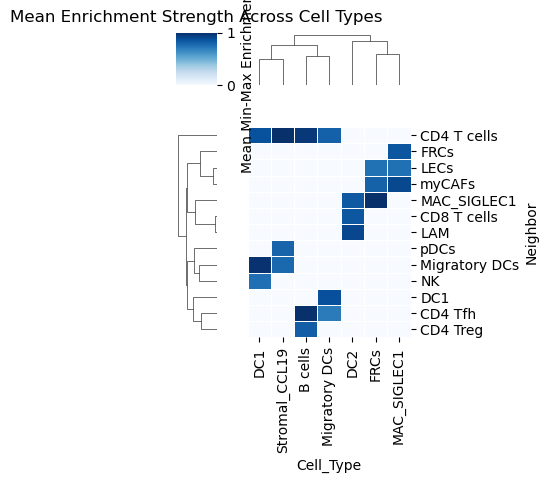

In [43]:
heatmap_scores = top_neighbors_df.pivot(
    index="Neighbor", columns="Cell_Type", values="mean_score"
).fillna(0)

sns.clustermap(
    heatmap_scores,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    row_cluster=True,
    col_cluster=True,
    figsize=(4, 5),
    cbar_kws={"label": "Mean Min-Max Enrichment Score"}
)
plt.title("Mean Enrichment Strength Across Cell Types", y=1.05)
plt.tight_layout()
plt.savefig("Nhood_enrichment_TNBC.pdf")
plt.show()


## Lymphoid stromal cell analysis in lymph node 

In [44]:
SLS_ref.obs['TLS_cell_class_threshold'].cat.categories

Index(['Adipocytes', 'B cells', 'CAFs_MYO', 'CAFs_NRT', 'CD4 T cells',
       'CD4 Tfh', 'CD4 Treg', 'CD8 T cells', 'DC1', 'DC2', 'Endothelial',
       'FDCs', 'FRCs', 'Malignant cells', 'Mast', 'Migratory DCs', 'NK',
       'Neutrophils', 'Plasma', 'SMCs', 'Stromal_CCL19', 'TAMs_C1QC',
       'TAMs_MHC', 'TAMs_OLR1', 'TAMs_SPP1', 'pDCs'],
      dtype='object')

In [45]:
SLS_plotting = SLS_ref[SLS_ref.obs['TLS_cell_class_threshold'].isin(['CAFs_MYO', 'CAFs_NRT','FDCs', 'FRCs', 'Stromal_CCL19',"B cells"])]
SLS_plotting.uns['TLS_cell_class_threshold_colors']=[ '#ff7f0e','#d5eae7','#d5eae7',"#DD51AD","#00BFA0",'#D8D18C']

/tmp/ipykernel_16191/2936184478.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  SLS_plotting.uns['TLS_cell_class_threshold_colors']=[ '#ff7f0e','#d5eae7','#d5eae7',"#DD51AD","#00BFA0",'#D8D18C']


/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

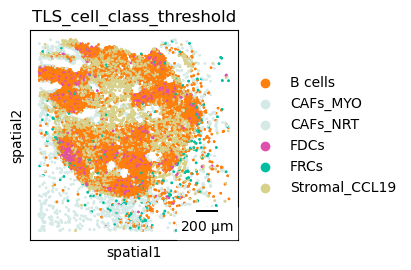

In [46]:
sq.pl.spatial_scatter(
    SLS_plotting, shape=None, color=['TLS_cell_class_threshold','MS4A1','FDCSP','PLA2G2A','CCL19'], size=3,library_id="spatial", figsize=(4, 4),
    wspace=0.6,
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:649: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


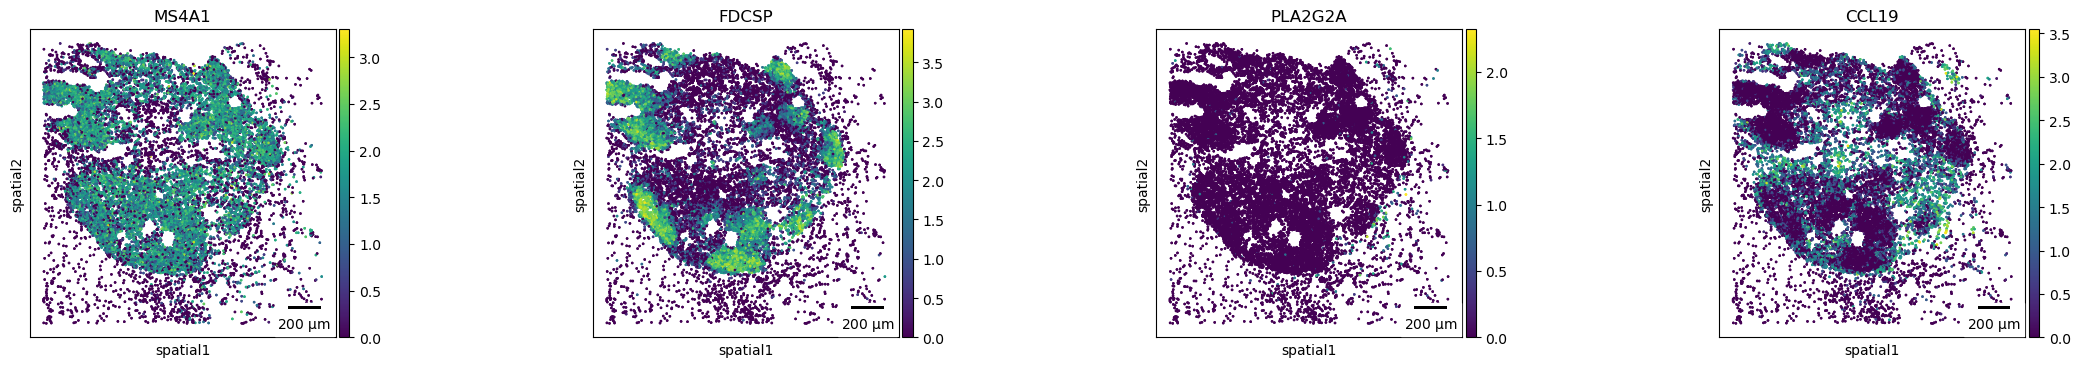

In [47]:
sq.pl.spatial_scatter(
    SLS_plotting, shape=None, color=[,'MS4A1','FDCSP','PLA2G2A','CCL19'], size=3,library_id="spatial", figsize=(4, 4),
    wspace=0.6,
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"}
)

In [58]:
B_plotting = SLS_plotting[SLS_plotting.obs['TLS_cell_class_threshold'].isin(['FDCs', 'FRCs', 'Stromal_CCL19',"B cells"])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

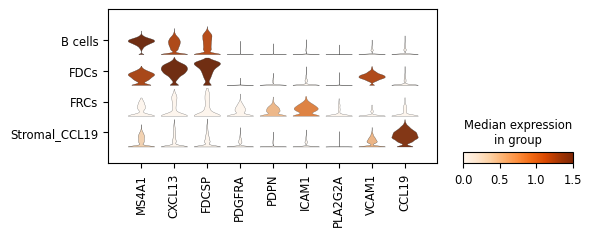

In [61]:
sc.pl.stacked_violin(
    B_plotting, ['MS4A1','CXCL13','FDCSP','PDGFRA','PDPN','ICAM1','PLA2G2A','VCAM1','CCL19'], groupby="TLS_cell_class_threshold", swap_axes=False, #dendrogram=True
    vmax=1.5,
    figsize=(6,2), 
    cmap='Oranges',
)

### Plotting genes with signficant Moran's I score

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:649: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


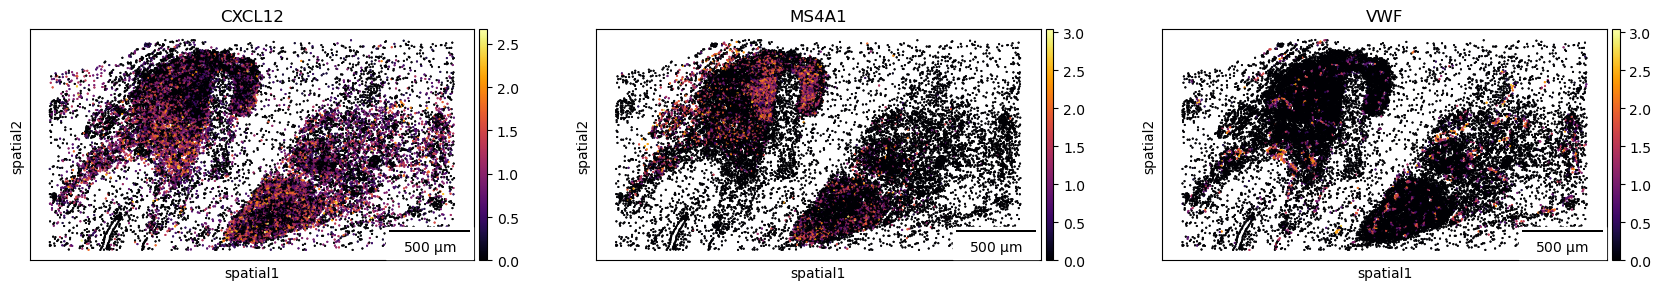

In [46]:
sq.pl.spatial_scatter(
    TLS_097_480_n2,
    library_id="spatial",
    color=['CXCL12','MS4A1','VWF'],
    shape=None,
    size=1,
    img=False,  cmap="inferno",
    #wspace=0.08,
    figsize = (6, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    save='Moran_#4.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:649: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


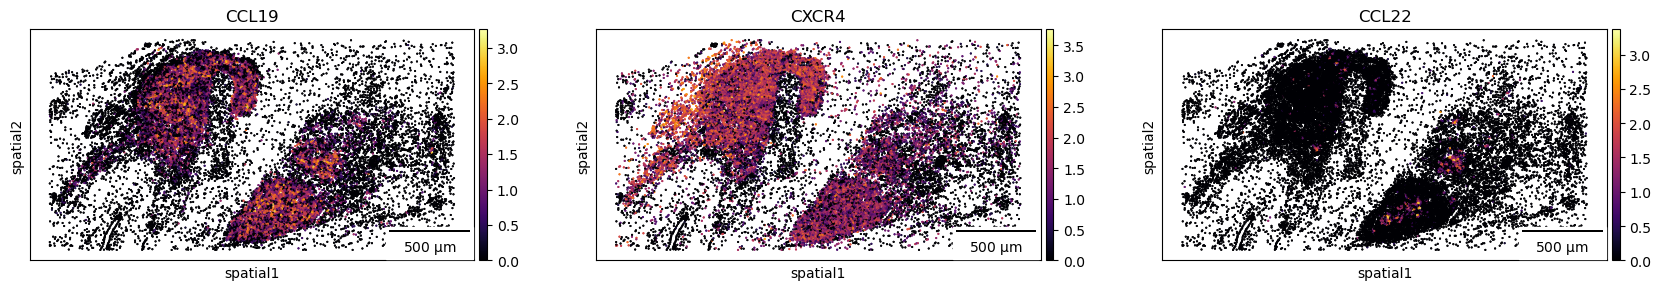

In [49]:
sq.pl.spatial_scatter(
    TLS_097_480_n2,
    library_id="spatial",
    color=['CCL19','CXCR4','CCL22'],
    shape=None,
    size=1,
    img=False,  cmap="inferno",
    #wspace=0.08,
    figsize = (6, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    save='Moran_#2.pdf'
)

#### TLS cytokine expression profile 

In [67]:
TLS_cytokines = ['VCAM1','CCL19','CCL21',# TLS-cytokines
                 'CXCL12',
                 'PDGFRA',
                 'CXCL14','PLA2G2A','IGF1','PDPN','MS4A1','CXCL13','CD40','BTLA',
                 'CCL22', 
                 'CD80','CD86','CD28','IL7R','TCF7','LEF1','CD274','PDCD1','TIGIT','CTLA4','ICOS','CD40LG',
                 'CCL5','PRF1','GZMA','GZMB',
                 'VWF','ACKR1','ICAM1','IL6','HAVCR2',
                 'SIGLEC1','MERTK','C1QA','C1QC',
                 ]

In [69]:
TLS_97_n3_subset = TLS_097_480_n3[TLS_097_480_n3.obs['TLS_cell_class_threshold'].isin(['B cells','CD4 T cells',
       'CD4 Tfh', 'CD8 T cells', 'Endothelial', 'FDCs', 'FRCs','LECs', 'Migratory DCs','Stromal_CCL19', 'TAMs_C1QC' ])]

/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


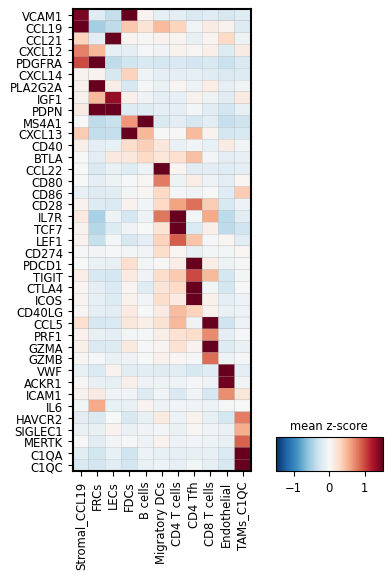

In [70]:
sc.pl.matrixplot(TLS_97_n3_subset, TLS_cytokines, groupby='TLS_cell_class_threshold', dendrogram=False,swap_axes = True,
                 colorbar_title='mean z-score', layer='scaled', vmin=-1.5, vmax=1.5, 
                 cmap='RdBu_r',  
                 categories_order = ['Stromal_CCL19','FRCs','LECs','FDCs','B cells',
                                     'Migratory DCs','CD4 T cells', 'CD4 Tfh', 'CD8 T cells',
                                     'Endothelial', 'TAMs_C1QC'], 
                 figsize=(4,6), 
                ) 

In [71]:
TLS_96_n1_subset = TLS_096_480_n1[TLS_096_480_n1.obs['TLS_cell_class_threshold'].isin(['B cells','CD4 T cells',
       'CD4 Tfh', 'CD8 T cells', 'Endothelial', 'FDCs', 'FRCs','LECs', 'Migratory DCs','Stromal_CCL19', 'TAMs_C1QC' ])]

/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


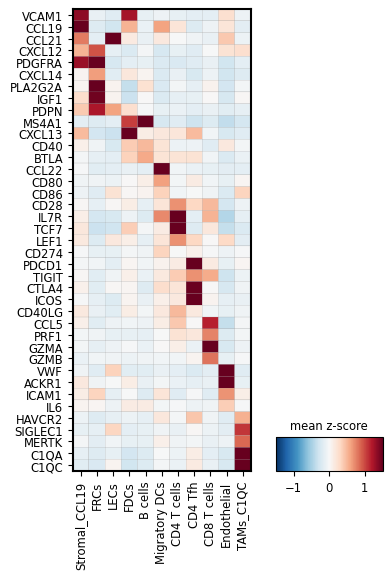

In [72]:
sc.pl.matrixplot(TLS_96_n1_subset, TLS_cytokines, groupby='TLS_cell_class_threshold', dendrogram=False,swap_axes = True,
                 colorbar_title='mean z-score', layer='scaled', vmin=-1.5, vmax=1.5, 
                 cmap='RdBu_r',  
                 categories_order = ['Stromal_CCL19','FRCs','LECs','FDCs','B cells',
                                     'Migratory DCs','CD4 T cells', 'CD4 Tfh', 'CD8 T cells',
                                     'Endothelial', 'TAMs_C1QC'], 
                 figsize=(4,6)) 

In [73]:
SLS_subset = SLS_ref[SLS_ref.obs['TLS_cell_class_threshold'].isin(['B cells','CD4 T cells',
       'CD4 Tfh', 'CD8 T cells', 'Endothelial', 'FDCs', 'FRCs','LECs', 'Migratory DCs','Stromal_CCL19', 'TAMs_C1QC' ])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


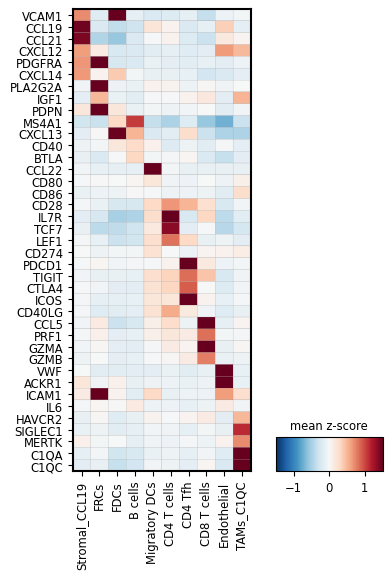

In [74]:
sc.pl.matrixplot(SLS_subset, TLS_cytokines, groupby='TLS_cell_class_threshold', dendrogram=False,swap_axes = True,
                 colorbar_title='mean z-score', layer='scaled', vmin=-1.5, vmax=1.5, 
                 #cmap = 'viridis',
                 cmap='RdBu_r',  
                 categories_order = ['Stromal_CCL19','FRCs','FDCs','B cells',
                                     'Migratory DCs','CD4 T cells', 'CD4 Tfh', 'CD8 T cells',
                                     'Endothelial', 'TAMs_C1QC'], 
                 figsize=(4,6), 
                 save = 'SLS_subset.pdf'
                ) 

In [75]:
TNBC4 = TLS_TNBC_4[TLS_TNBC_4.obs['TLS_cell_class_threshold'].isin(['B cells','CD4 T cells',
       'CD4 Tfh', 'CD8 T cells', 'Endothelial', 'FDCs', 'FRCs','LECs', 'Migratory DCs','Stromal_CCL19', 'MAC_SIGLEC1' ])]

In [76]:
TLS_cytokines_tnbc = ['CCL19','CCL21',# TLS-cytokines
                 #'CXCL12',#'CXCL2','IL6',
                 'PDGFRA',
                 'CXCL14','PLA2G2A','IGF1','PDPN','MS4A1','CXCL13','CD40','BTLA',
                 'CCL22', #'TNFSF14',
                 'CD80','CD86','CD28','IL7R','TCF7','LEF1','CD274','PDCD1','TIGIT','CTLA4','ICOS','CD40LG',
                 'CCL5','PRF1','GZMA','GZMB','KLRK1',
                 'VWF','ACKR1','ICAM1','IL6','HAVCR2',
                 'SIGLEC1','MERTK','C1QA','C1QC',
                 #'VSIR','SIRPA','LGALS9','TNFRSF14'
                 ]

/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


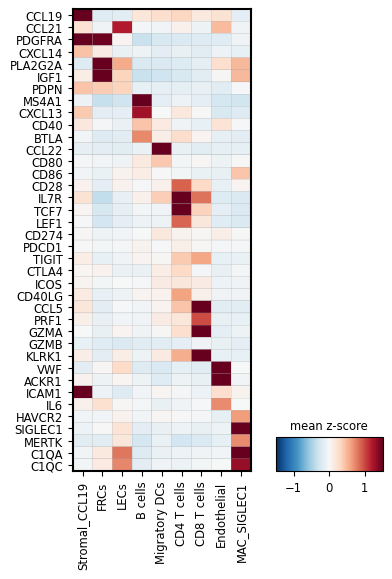

In [77]:
sc.pl.matrixplot(TNBC4, TLS_cytokines_tnbc, groupby='TLS_cell_class_threshold', dendrogram=False,swap_axes = True,
                 colorbar_title='mean z-score', layer='scaled', vmin=-1.5, vmax=1.5, 
                 #cmap = 'viridis',
                 cmap='RdBu_r',  
                 categories_order = ['Stromal_CCL19','FRCs','LECs','B cells',
                                     'Migratory DCs','CD4 T cells', 'CD8 T cells',
                                     'Endothelial', 'MAC_SIGLEC1'], 
                 figsize=(4,6), 
                 #save = 'TLS_cytokines_TNBC_4.pdf'
                ) 

#### CCL19 and CCR7 expression pattern

##### TNBC TLS

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

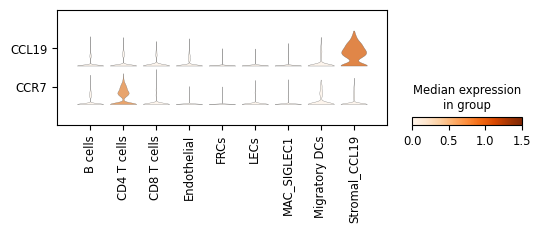

In [225]:
sc.pl.stacked_violin(
    TNBC4, ['CCL19','CCR7'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
    vmax=1.5,
    figsize=(6,1.5), 
    cmap='Oranges',
    save='Vln_TNBC4_CCL19_CCR7.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

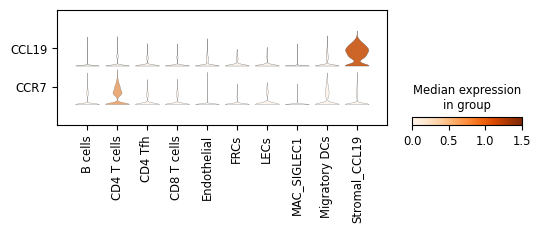

In [226]:
sc.pl.stacked_violin(
    TNBC1, ['CCL19','CCR7'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
    vmax=1.5,
    figsize=(6,1.5), 
    cmap='Oranges',
    save='Vln_TNBC1_CCL19_CCR7.pdf'
)

##### PDAC TLS

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

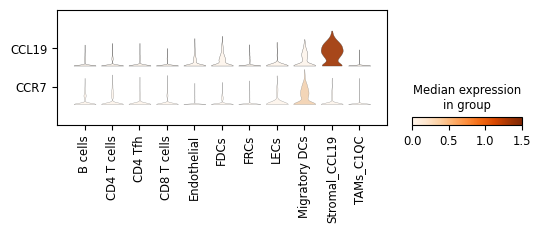

In [227]:
sc.pl.stacked_violin(
    TLS_96_n2_subset, ['CCL19','CCR7'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    save='Vln_96n2_CCL19_CCR7.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


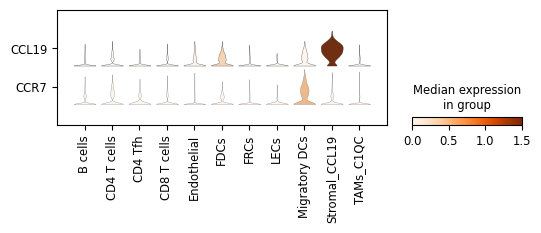

In [228]:
sc.pl.stacked_violin(
    TLS_96_n1_subset, ['CCL19','CCR7'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    save='Vln_96n1_CCL19_CCR7.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

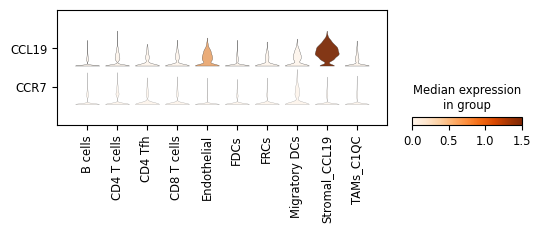

In [234]:
sc.pl.stacked_violin(
    SLS_subset, ['CCL19','CCR7'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    save='vlnplot_SLS_CCL19_CCR7.pdf'
)

#### CXCL12-CXCR4 in TLS

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

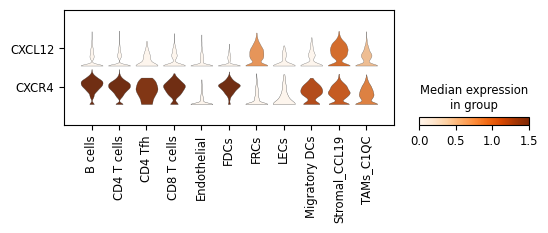

In [230]:
sc.pl.stacked_violin(
    TLS_97_n2_subset, ['CXCL12','CXCR4'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    save='Vln_97n2_CXCL12_CXCR4.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

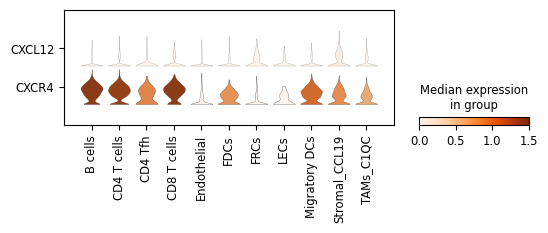

In [195]:
sc.pl.stacked_violin(
    TLS_97_n3_subset, ['CXCL12','CXCR4'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    #save='vlnplot.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

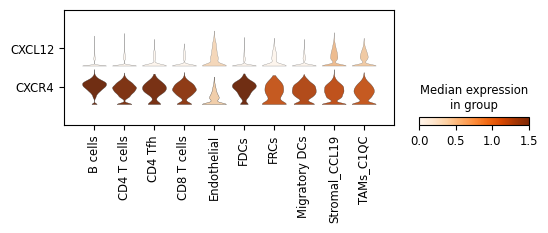

In [235]:
sc.pl.stacked_violin(
    SLS_subset, ['CXCL12','CXCR4'], groupby="TLS_cell_class_threshold", swap_axes=True, #dendrogram=True
     figsize=(6,1.5), 
    vmax=1.5,
    cmap='Oranges',
    save='vlnplot_SLS_CXCL12_CXCR4.pdf'
)

### TNBC TLS 

In [113]:
TLS_TNBC_4.uns['TLS_cell_class_threshold_colors']=['#ff7f0e','#7d87b9','#536CC7','#023fa5',"#888D07","#717417", '#d62728',"#00BFA0","#535A06",
                                                     '#f79cd4', '#c5b0d5','#8c564b',
                                                     '#000035',"#105354",'#f3e1eb', "#00025E",'#d5eae7','#9cded6','#D8D18C',"#cccccc", "#B4584D",'#FFE5A7','#1b4400']

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

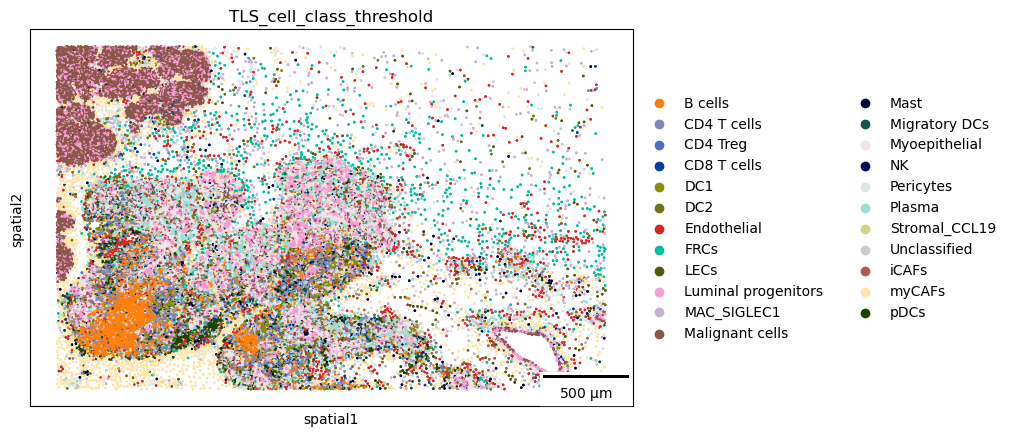

In [114]:
sq.pl.spatial_scatter(
    TLS_TNBC_4,
    library_id="spatial",
    color=['TLS_cell_class_threshold'],
    shape=None,
    size=3,
    img=False,  cmap="inferno",
    #wspace=0.08,
    figsize = (10, 5),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    #save='Moran_#5.pdf'
)

In [115]:
genes = ['ACTA2','KRT5',
         'KIT','CDH1','KRT19','KRT7','EPCAM','ACTN4',
         'MS4A1','CD52','CXCL13','CD19',
         'IRF8','GZMB','CIITA',
         'CLEC10A','CD1C',
         'CLEC9A','IDO1',
         'LAMP3','CCL22',
         'CD8A','CD8B','GZMA',
         'NKG7','GNLY','KLRD1',
         'IL7R','TCF7',
         'FOXP3','IKZF2',
         'MZB1','PRDM1','SDC1',
         'PLVAP','VWF','KDR',
         'PDGFRB','RGS5',
         'LYVE1','FLT4','CCL21',
         'CD163','SELENOP','C1QA','C1QC','SIGLEC1',
         'PLA2G2A','IGF1','COL6A3',
         'POSTN','FN1','MMP2',
         'CPA3','KIT',
         'ICAM1','CCL19',
         'PDGFRA','C7','ABCA6','ABCA10'
        ]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


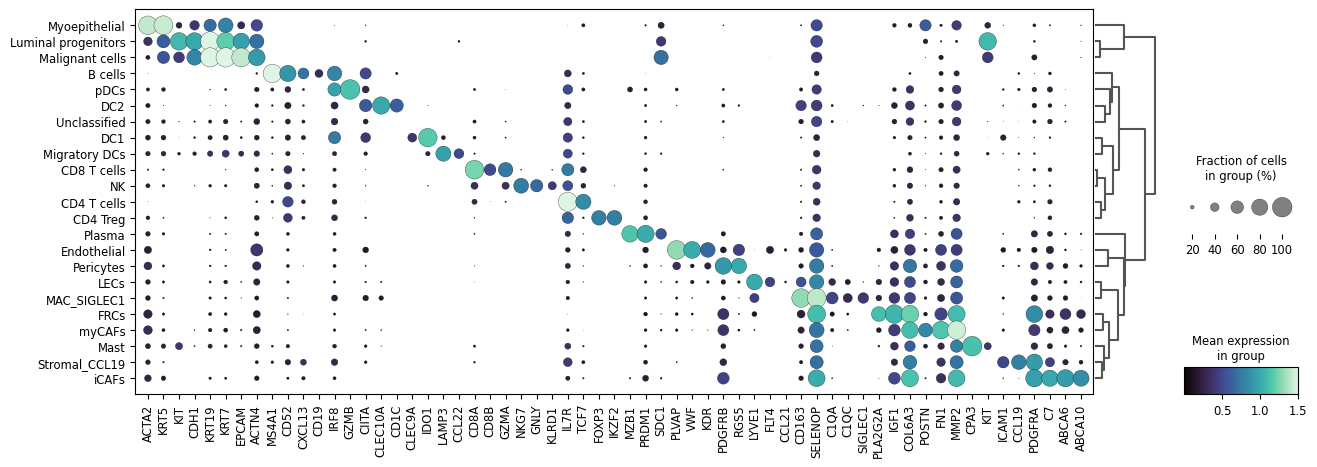

In [116]:
sc.pl.dotplot(TLS_TNBC_4, var_names = genes , groupby='TLS_cell_class_threshold', #swap_axes = True, 
              figsize=(15, 5), vmax=1.5, dot_min=0.1, cmap = 'mako',
             dendrogram=True, 
             #save = 'REP_TNBC_TLS_3962.pdf'
             ) # annotation based on Wu et al., 2021 Nat Genet https://www.nature.com/articles/s41588-021-00911-1

In [78]:
TNBC4.uns['TLS_cell_class_threshold_colors']=['#ff7f0e','#7d87b9','#7d87b9','#d62728',"#00BFA0", "#535A06",'#c5b0d5',"#105354",'#D8D18C']

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

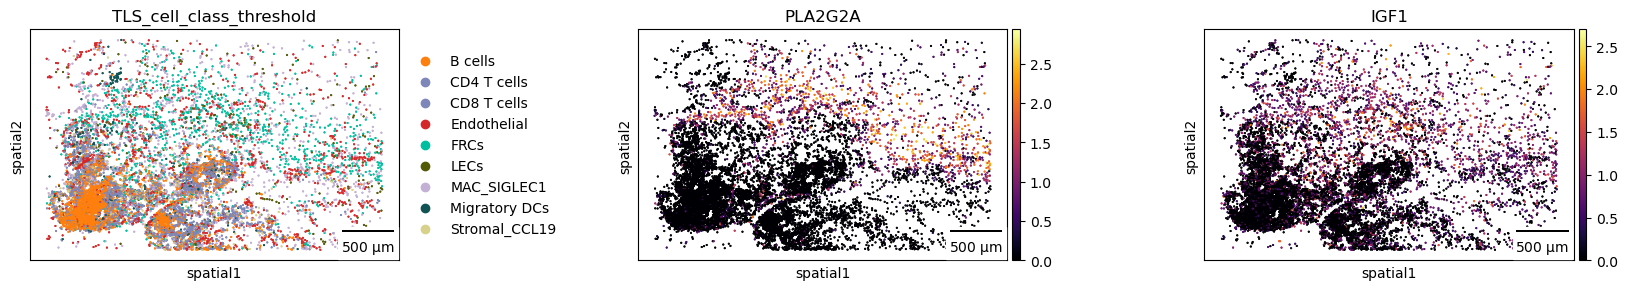

In [79]:
sq.pl.spatial_scatter(
    TNBC4,
    library_id="spatial",
    color=['TLS_cell_class_threshold','PLA2G2A','IGF1'],
    shape=None,
    size=1,
    img=False,  cmap="inferno",
    #wspace=0.08,
    figsize = (6, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    #save='Moran_#5.pdf'
)

In [82]:
rep4 = TNBC4[TNBC4.obs['TLS_cell_class_threshold'].isin(['B cells', 'FDCs', 'FRCs','Stromal_CCL19'])]

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

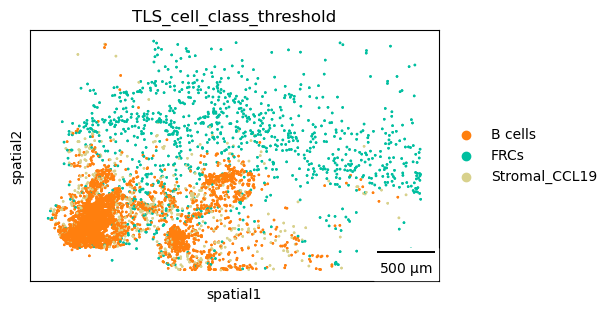

In [105]:
sq.pl.spatial_scatter(
    rep4,
    library_id="spatial",
    color=['TLS_cell_class_threshold'],
    shape=None,
    size=3,
    img=False,  cmap="inferno",
    #wspace=0.08,
    figsize = (6, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    #save='TNBC_stromal.pdf'
)

/tmp/ipykernel_16191/1006010356.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  plotting.uns['TLS_cell_class_threshold_colors'] = ['#ff7f0e',"#DD51AD","#00BFA0",'#D8D18C']
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map

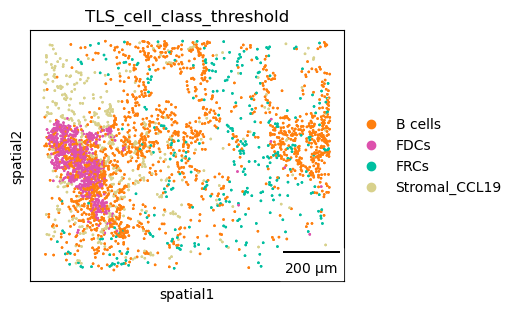

In [101]:
plotting =  TLS_096_480_n1[TLS_096_480_n1.obs['TLS_cell_class_threshold'].isin(['B cells','FDCs', 'FRCs', 'Stromal_CCL19'])]
plotting.uns['TLS_cell_class_threshold_colors'] = ['#ff7f0e',"#DD51AD","#00BFA0",'#D8D18C']

sq.pl.spatial_scatter(
    plotting, shape=None, color=['TLS_cell_class_threshold'], size=3,library_id="spatial", figsize=(6, 3),
    wspace=0.8,
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    crop_coord=(4000,1800,5000,2600), 
)

/tmp/ipykernel_16191/2559233502.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  plotting.uns['TLS_cell_class_threshold_colors'] = ['#ff7f0e',"#DD51AD","#00BFA0",'#D8D18C']
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map

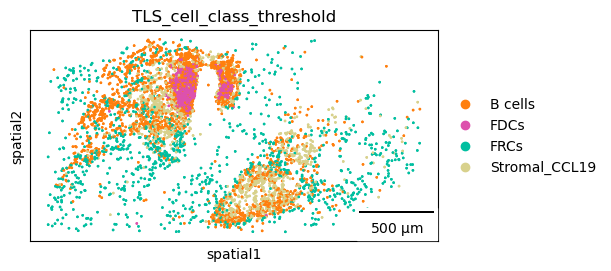

In [103]:
plotting =  TLS_097_480_n2[TLS_097_480_n2.obs['TLS_cell_class_threshold'].isin(['B cells','FDCs', 'FRCs', 'Stromal_CCL19'])]
plotting.uns['TLS_cell_class_threshold_colors'] = ['#ff7f0e',"#DD51AD","#00BFA0",'#D8D18C']

sq.pl.spatial_scatter(
    plotting, shape=None, color=['TLS_cell_class_threshold'], size=3,library_id="spatial", figsize=(6, 3),
    wspace=0.8,
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    #crop_coord=(4000,1800,5000,2600), 
)

### Dot plot to confirm cell identity

In [98]:
plotting_id = TLS_097_480_n2[TLS_097_480_n2.obs['TLS_cell_class_threshold'].isin(['B cells','CD4 T cells','CD8 T cells','Plasma',
         'Stromal_CCL19','FDCs','FRCs',
         'Migratory DCs','DC1','DC2',
         'TAMs_C1QC','Pericytes','Endothelial','CAFs_NRT'])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:105: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[group]):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:161: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


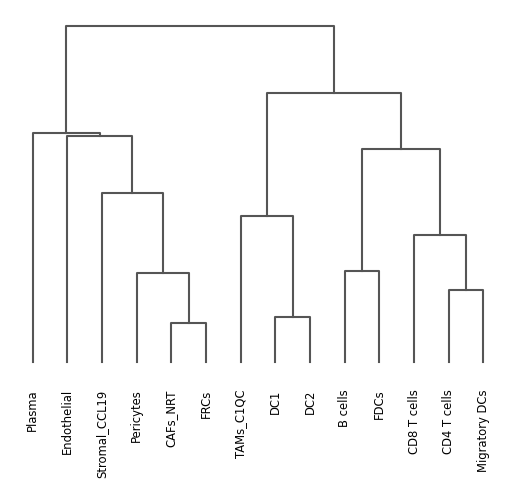

<Axes: >

In [88]:
# Running dendogram
sc.tl.dendrogram(plotting_id, groupby = "TLS_cell_class_threshold")
sc.pl.dendrogram(plotting_id, groupby = "TLS_cell_class_threshold")

In [89]:
markers = ['JCHAIN','MZB1','VWF','PLVAP',
           'ICAM1','CCL19','CXCL12',
           'PDGFRB','RGS5',
           'PDGFRA','C7','SCN7A','ABCA10','ABCA8',
           'PDPN','PLA2G2A','MEDAG','IGF1',
           'CD163','F13A1','C1QC','C1QA','SELENOP',
           'CLEC9A','IRF8','IDO1','CLNK','CD1C','CLEC10A',
           'MS4A1','CD19','CD22','VCAM1','FDCSP',
           'CD8A','CD8B','GZMA','GZMK',
           'CD4','IL7R','TCF7',
           'LAMP3','CCL22']

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


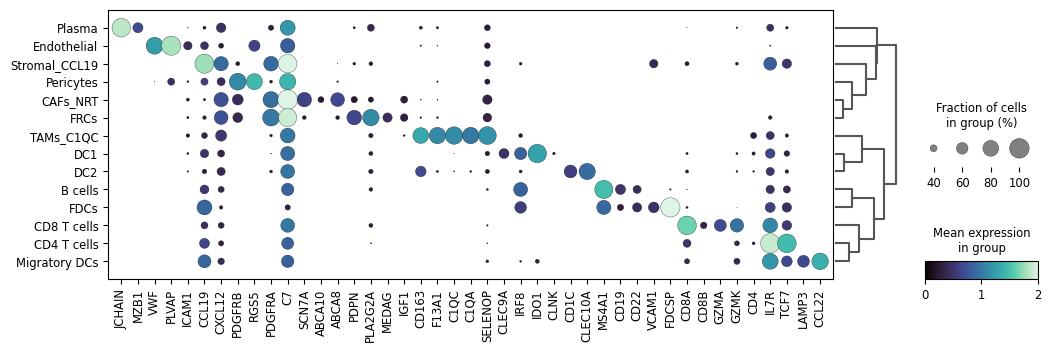

In [90]:
sc.pl.dotplot(plotting_id, var_names =markers, groupby='TLS_cell_class_threshold', swap_axes = False, 
             figsize=(12,3.5), dot_min=0.2, vmax=2.0, cmap = 'mako', save='97_n2_dotplot.pdf',
             dendrogram=True)

### Comparing cellular composition of TLS in PDAC and TNBC

In [93]:
# Initialize lists to hold counts
tls_names = [
    "TLS_107_314", "TLS_104_314","TLS_065_314","TLS_096_480_n2",
    "TLS_096_480_n1","TLS_097_480_n3","TLS_097_480_n2","TLS_097_480_n1","SLS_ref"
]

tnbc_names = ["TNBC_1","TNBC_2","TNBC_3", "TNBC_4"]

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

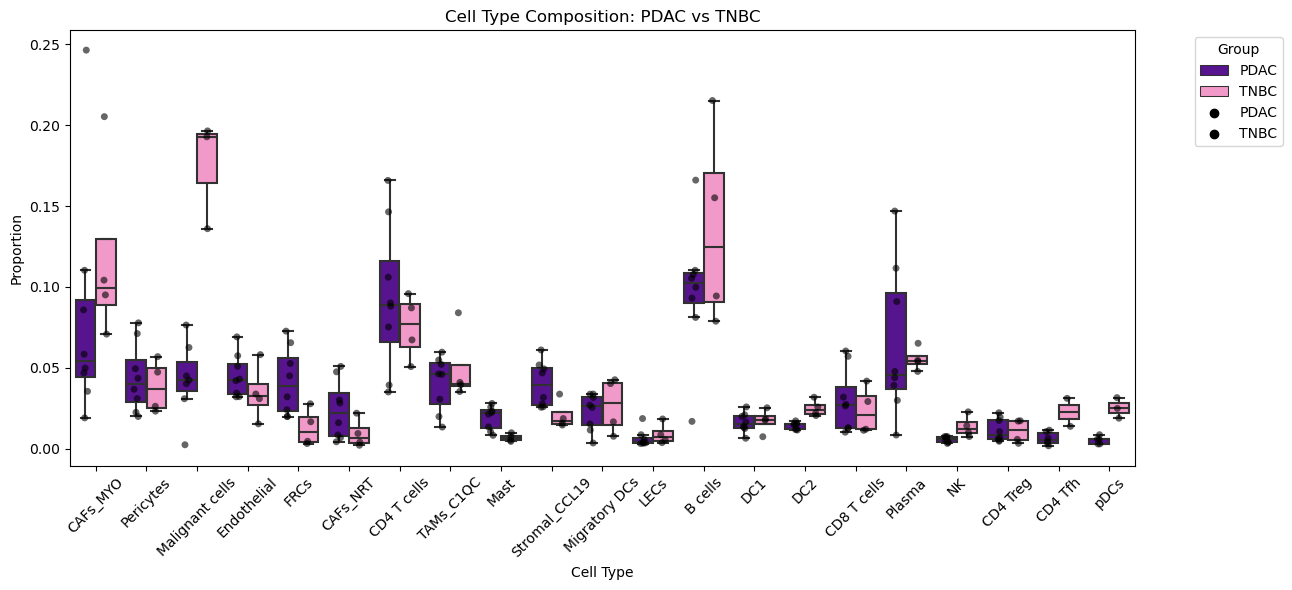

In [95]:
#### Define sample list #######
pdac_tls_list = [
    TLS_107_314, TLS_104_314, TLS_065_314, TLS_096_480_n2,
    TLS_096_480_n1,TLS_097_480_n3,TLS_097_480_n2,TLS_097_480_n1]


tnbc_tls_list = [TLS_TNBC_1, TLS_TNBC_2, TLS_TNBC_3, TLS_TNBC_4]

## Need to rename first as TNBC label was used based on the mini atlas label
rename_map = {
    "MAC_SIGLEC1": "TAMs_C1QC",
    "myCAFs": "CAFs_MYO",
    "iCAFs": "CAFs_NRT"
}

# Apply renaming in each TNBC AnnData object
for adata in tnbc_tls_list:
    adata.obs["TLS_cell_class_threshold"] = adata.obs["TLS_cell_class_threshold"].replace(rename_map)


### Define the function to quantify ########
def compute_composition(adata_list, group_label):
    composition_data = []

    for idx, adata in enumerate(adata_list):
        cell_counts = adata.obs["TLS_cell_class_threshold"].value_counts(normalize=True)
        for cell_type, proportion in cell_counts.items():
            composition_data.append({
                "sample_id": f"{group_label}_{idx}",
                "group": group_label,
                "cell_type": cell_type,
                "proportion": proportion
            })

    return pd.DataFrame(composition_data)

# Compute compositions for both groups
pdac_df = compute_composition(pdac_tls_list, "PDAC")
tnbc_df = compute_composition(tnbc_tls_list, "TNBC")

# Find common cell types
common_cell_types = set(pdac_df["cell_type"]).intersection(tnbc_df["cell_type"])

# Filter to common cell types only
common_cell_types = common_cell_types - {"Unclassified"}
combined_df = pd.concat([pdac_df, tnbc_df], ignore_index=True)
filtered_df = combined_df[combined_df["cell_type"].isin(common_cell_types)]

# Plot boxplots for each common cell type
pal = {"PDAC" : "#5800a2", #"#ce73ff",
       "TNBC" : "#ff8bc9"}

pal_2 = {"PDAC" : "black",
       "TNBC" : "black"}
# Plot
plt.figure(figsize=(13, 6))

# Boxplot (without outlier dots to reduce clutter)
sns.boxplot(
    data=filtered_df,
    x="cell_type", y="proportion", hue="group",
    palette=pal,
    showfliers=False
)

# Add all individual points
sns.stripplot(
    data=filtered_df,
    x="cell_type", y="proportion", hue="group",
    dodge=True, jitter=True, alpha=0.6,
    palette=pal_2, #marker='o'
)

# Adjust plot
plt.title("Cell Type Composition: PDAC vs TNBC")
plt.xticks(rotation=45)
plt.ylabel("Proportion")
plt.xlabel("Cell Type")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"Composition_comparison_PDAC_TNBC.pdf")
plt.show()

In [96]:
from scipy.stats import mannwhitneyu
import numpy as np

# Perform statistical testing for each cell type
stat_results = []

for cell_type in common_cell_types:
    group_pdac = filtered_df[(filtered_df["cell_type"] == cell_type) & (filtered_df["group"] == "PDAC")]["proportion"]
    group_tnbc = filtered_df[(filtered_df["cell_type"] == cell_type) & (filtered_df["group"] == "TNBC")]["proportion"]

    stat, pval = mannwhitneyu(group_pdac, group_tnbc, alternative='two-sided')

    stat_results.append({
        "cell_type": cell_type,
        "p_value": pval
    })

# Convert to DataFrame
pval_df = pd.DataFrame(stat_results)

# Optional: Add significance stars
def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

pval_df["significance"] = pval_df["p_value"].apply(pval_to_stars)

In [ ]:
pval_df

,cell_type,p_value,significance
0,pDCs,0.035714,*
1,CD8 T cells,0.682828,ns
2,NK,0.008081,**
3,DC1,0.808081,ns
4,CD4 Tfh,0.071429,ns
5,LECs,0.460606,ns
6,DC2,0.004040,**
7,Malignant cells,0.016667,*
8,Endothelial,0.282828,ns
9,Pericytes,0.933333,ns
